Loading Dataset


In [2]:
import pandas as pd

df = pd.read_csv("E:\\projects\\SP500-Analytics\\data\\all_stocks_5yr.csv")

df.head()

,date,open,high,low,close,volume,Name
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL


In [3]:
df.shape
df.columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 619040 entries, 0 to 619039
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   date    619040 non-null  str    
 1   open    619029 non-null  float64
 2   high    619032 non-null  float64
 3   low     619032 non-null  float64
 4   close   619040 non-null  float64
 5   volume  619040 non-null  int64  
 6   Name    619040 non-null  str    
dtypes: float64(4), int64(1), str(2)
memory usage: 33.1 MB


Data Cleaning

In [4]:
df['date'] = pd.to_datetime(df['date'])
df.sort_values(['Name','date'], inplace=True)

df.isnull().sum()

date       0
open      11
high       8
low        8
close      0
volume     0
Name       0
dtype: int64

In [5]:
# Daily Returns
df['returns'] = df.groupby('Name')['close'].pct_change()

# 30-day moving average
df['ma_30'] = df.groupby('Name')['close'].rolling(30).mean().reset_index(level=0, drop=True)

# 30-day volatility
df['volatility_30'] = df.groupby('Name')['returns'].rolling(30).std().reset_index(level=0, drop=True)

In [6]:
risk_return = df.groupby('Name')['returns'].agg(['mean','std'])

risk_return.rename(columns={'mean':'Average Return', 'std':'Risk'}, inplace=True)

risk_return.sort_values('Average Return', ascending=False).head()

,Average Return,Risk
Name,,
NVDA,0.002563,0.022350
NFLX,0.002217,0.027353
AMD,0.001882,0.037784
ALGN,0.001775,0.020702
EA,0.001754,0.020057


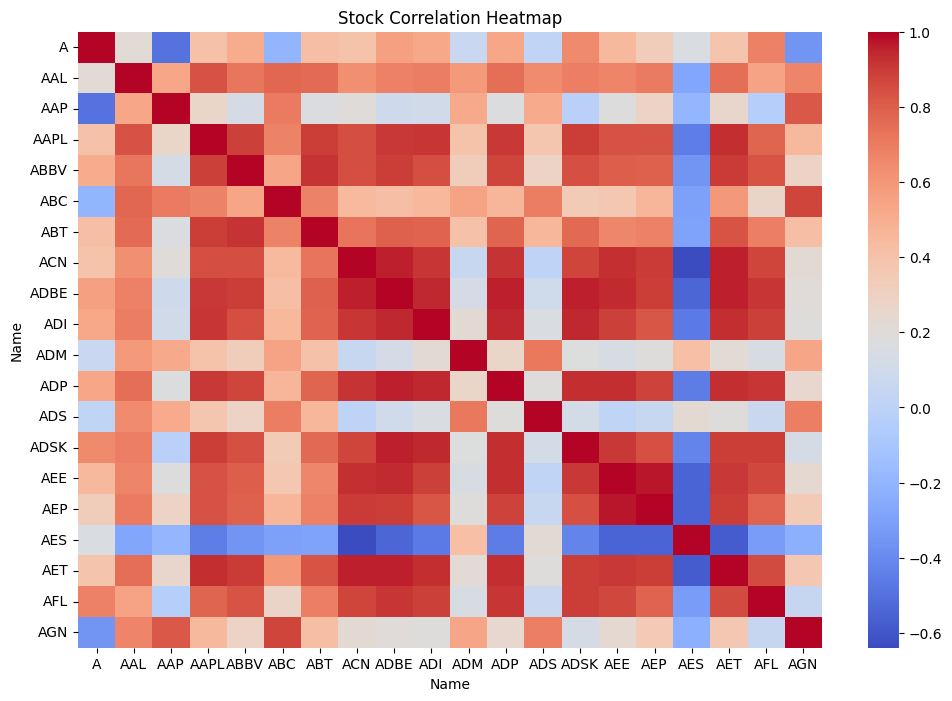

In [7]:
top_stocks = df['Name'].unique()[:20]

pivot_df = df[df['Name'].isin(top_stocks)].pivot(index='date', columns='Name', values='close')

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(pivot_df.corr(), cmap='coolwarm')
plt.title("Stock Correlation Heatmap")
plt.show()

In [8]:
risk_return.to_csv("outputs/tables/risk_return_summary.csv")

OSError: Cannot save file into a non-existent directory: 'outputs\tables'

In [9]:
correlation_matrix = pivot_df.corr()

correlation_matrix.to_csv("E:\\projects\\SP500-Analytics\\outputs\\tables\\correlation_matrix.csv")

In [10]:
plt.figure(figsize=(12,8))
sns.heatmap(pivot_df.corr(), cmap='coolwarm')
plt.title("Stock Correlation Heatmap")

plt.savefig("E:\\projects\\SP500-Analytics\\outputs\\charts\\correlation_heatmap.png", dpi=300, bbox_inches='tight')
plt.close()

In [11]:
plt.figure(figsize=(10,6))
plt.scatter(risk_return['Risk'], risk_return['Average Return'])

plt.xlabel("Risk (Std Dev)")
plt.ylabel("Average Return")
plt.title("Risk vs Return Analysis")

plt.savefig("E:\\projects\\SP500-Analytics\\outputs\\charts\\risk_return_scatter.png", dpi=300, bbox_inches='tight')
plt.close()

In [13]:
apple = df[df['Name'] == 'AAPL'].dropna()

import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X = np.arange(len(apple)).reshape(-1,1)
y = apple['close'].values

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,shuffle=False)

model = LinearRegression()
model.fit(X_train, y_train)

print("R2:", model.score(X_test,y_test))

R2: -3.5706052914427087


In [15]:
predictions_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": model.predict(X_test)
})

predictions_df.to_csv("E:\\projects\\SP500-Analytics\\outputs\\tables\\apple_forecast_results.csv", index=False)

In [17]:
import joblib

joblib.dump(model, "E:\\projects\\SP500-Analytics\\outputs\\models\\apple_regression_model.pkl")

['E:\\projects\\SP500-Analytics\\outputs\\models\\apple_regression_model.pkl']

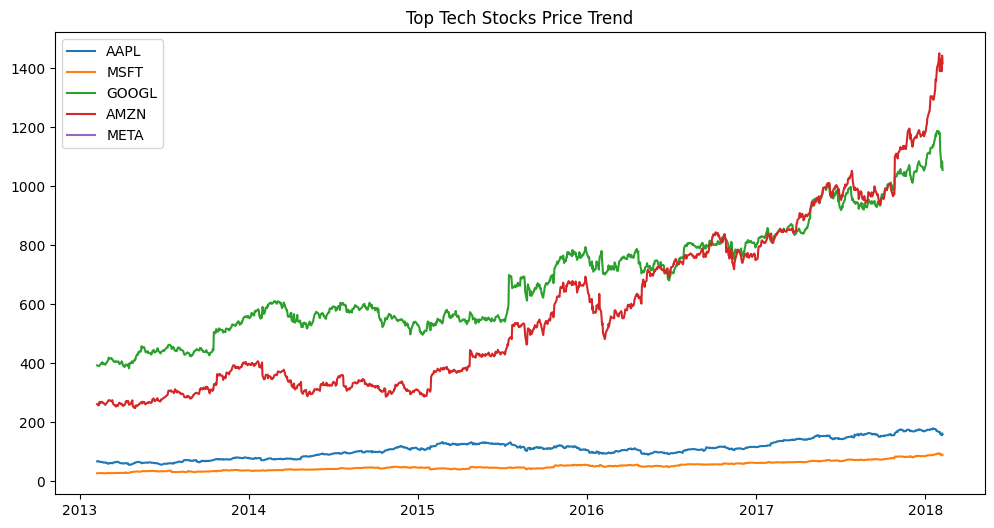

In [19]:
top_stocks = ['AAPL','MSFT','GOOGL','AMZN','META']

plt.figure(figsize=(12,6))

for stock in top_stocks:
    subset = df[df['Name'] == stock]
    plt.plot(subset['date'], subset['close'], label=stock)

plt.legend()
plt.title("Top Tech Stocks Price Trend")
plt.savefig("E:\\projects\\SP500-Analytics\\outputs\\charts\\top_tech_trend.png", dpi=300)
plt.show()

In [18]:
print("Analysis Completed Successfully. Outputs saved.")

Analysis Completed Successfully. Outputs saved.
